## Today's Task
============================================================================================================

The experiment/codes below encodes sequences --> runs them through a few clasification models --> plots the performance of each encoding/representation

There are several datasets available for playing around!

- Select any <strong>3 datasets</strong> (one at a time) from the drop down.
- Run the cells below.
- Report the results you observe in each experiment.

## Cloning git repository

In [1]:
!git clone https://github.com/fabianagoes/ismb_tutorial8.git

Cloning into 'ismb_tutorial8'...
remote: Enumerating objects: 272, done.
remote: Counting objects: 100% (79/79), done.
remote: Compressing objects: 100% (60/60), done.
remote: Total 272 (delta 46), reused 48 (delta 19), pack-reused 193 (from 1)
Receiving objects: 100% (272/272), 54.73 MiB | 8.22 MiB/s, done.
Resolving deltas: 100% (82/82), done.
Updating files: 100% (106/106), done.


In [2]:
%cd ismb_tutorial8

/content/ismb_tutorial8


## Mounting Drive

Click 'OK' to give access!

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [119]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
import numpy as np
from numerical_mapping import *
from physico_chemical import *
from CGR import *
from basic_encoding import *
import os
from ML_models import *
import matplotlib.pyplot as plt
import seaborn as sns
from utils import *
import warnings
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
warnings.filterwarnings("ignore")

# Load Data


<div style="text-align: center;">
  <img src="https://github.com/fabianagoes/ismb_tutorial8/blob/main/images/datasets.png?raw=1" alt="Description" width="1000">
</div>

- Select a dataset
- Load train, validation and test data
- Look at data distribution
- Extract sequences to generate features

## Select Dataset

The following code goes over each dataset within the directory <strong>'datasets'</strong> and allows user to select a dataset from the dropdown.

In [4]:
root_dir = "/content/ismb_tutorial8/datasets"
subdirs = get_all_subdirs(root_dir) # internal function that goes over all subdirectories. Source code: utils.py

dropdown = widgets.Dropdown(
    options=subdirs,
    description='Select:',
    disabled=False,
)

selected_path = {'value': subdirs[0]}

def on_change(change):
    if change['type'] == 'change' and change['name'] == 'value':
        selected_path['value'] = change['new']

dropdown.observe(on_change)

display(dropdown)

Dropdown(description='Select:', options=('/content/ismb_tutorial8/datasets/GUE/splice/reconstructed', '/conten…

### Reading Dataset

Each dataset folder has <strong> train, validation and test set</strong>. We shall use pandas to read them.

In [5]:
print('Dataset Selected: ',selected_path['value'])

train_data=pd.read_csv(selected_path['value']+'/train.csv')#read_csv to read csv files
val_data=pd.read_csv(selected_path['value']+'/dev.csv')
test_data=pd.read_csv(selected_path['value']+'/test.csv')
data={'Train':train_data,'Val':val_data,'Test':test_data}

train_data.head(5)# displays first 5 datapoints

Dataset Selected:  /content/ismb_tutorial8/datasets/GUE/EMP/H3


,sequence,label
0,CTGAAATTTTTTTCGTTTCGCCACCAAGAAAGGCTAATTGAATACA...,1
1,ATATGCTCGAAAATGTAGCTATATTTCACGGATGAATAACTCGTAA...,0
2,CAACGGTACCCAATGGTTCCATCTCTAAGTCGTTAGGGCCAATCGT...,1
3,AACGAAGTCTAAATGGATCGAAGAAAGATTTCAAGAAAAGGTAAGT...,0
4,TGAGCAAATTTCCTTCCAACTTAGATGAACCCAGTAATTTTATTAA...,0


In [6]:
max_length=len(train_data['sequence'][0]) #setting max-length of sequences for computation
max_length

500

### Labels and Distribution

Storing the labels and data type (train/test/val) in a dataframe to look at how each label is distributed.

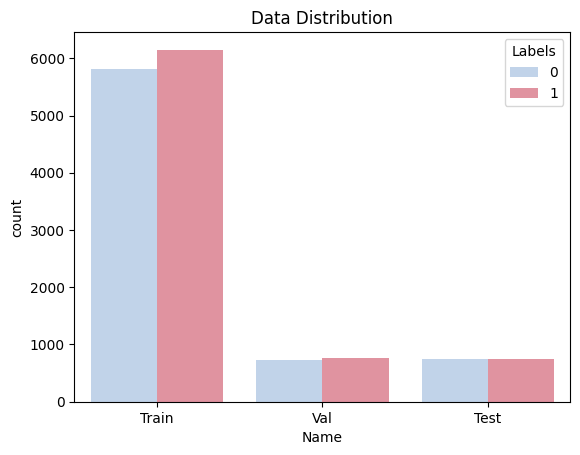

In [154]:
labels=[]
dataname=[]
colors=['#BAD2F0', '#ED8697']
for d in data:
    labels.extend((data[d])['label'])
    dataname.extend([d]*len(data[d].index))

label_distr=pd.DataFrame({'Labels':labels,'Name':dataname})
label_distr.reset_index() #resetting index to start from 0

sns.countplot(label_distr,x='Name',hue='Labels',palette=colors)#reference: seaborn
plt.title('Data Distribution')
plt.show()

### Read Sequences

Extracting sequences for further computing of features.

In [8]:
sequences={}

for d in data:
    sequences[d]=(data[d])['sequence']

pd.DataFrame(sequences).head(5)

,Train,Val,Test
0,CTGAAATTTTTTTCGTTTCGCCACCAAGAAAGGCTAATTGAATACA...,ACAATAATAATAATAATAATAATAATAATAACAATAACAATAGTGG...,TCGGTATGCGTTTCCAGAGAGAAGTTGTCGTCTAACTTCACGCCTG...
1,ATATGCTCGAAAATGTAGCTATATTTCACGGATGAATAACTCGTAA...,CCAAACCAACTTAGAACAATGCACCCAGTTTTTTTTCAGATTGATT...,TAAACCAAGCGTAAATCAGTATTGCTCTTACCGCAGTAGGGGGAGT...
2,CAACGGTACCCAATGGTTCCATCTCTAAGTCGTTAGGGCCAATCGT...,GCCTTGTATGCCATCCAAATTTTTGATTTCTTATGGTTCCCTTGGT...,AACTCTTCAAAAGAAATTCCTCAAATATGTCCAGTTTCATGTACTG...
3,AACGAAGTCTAAATGGATCGAAGAAAGATTTCAAGAAAAGGTAAGT...,GCATTCAGAGGGTGTGGATGATTGGGGTGCCGTTAAGTATTTATAT...,AAGGTTTTTCAAAGGATACATTTGAATTGATCAAGACATTTTTAGT...
4,TGAGCAAATTTCCTTCCAACTTAGATGAACCCAGTAATTTTATTAA...,GATATCTCAAGTGGGCAATACCCATGGAACCAGCAAGACCGGAAAC...,TCCTTCAAGAACTTAGCAAGAAGTACCAATTAGTCCCAGCGGGCCC...


# Extract Features

From sequences extract each feature dataframe for further analysis.


## Basic Encodings

### One-Hot

<strong>What</strong>: Binary vector representing each nucleotide (e.g., A = [1,0,0,0]).

<strong>When to Use</strong>: Deep learning, where fixed input formats are needed.

<strong>Drawbacks</strong>: High dimensionality, ignores sequence context, no similarity captured.

<div style="text-align: center;">
  <img src="https://github.com/fabianagoes/ismb_tutorial8/blob/main/images/OneHot.png?raw=1" alt="Description" width="500">
</div>

In [103]:
one_hot_feat=pd.DataFrame()
for seq_set in sequences:
    one_hot_feat=pd.concat([one_hot_feat,pd.DataFrame(one_hot_encode_sequences(sequences[seq_set]))],ignore_index=True)#for each set-> generates features and appends to the final dataset using concat function. Soruce of feature generating fucntion: basic_encoding
one_hot_feat.head(5)

,0,1,2,3,4,5,6,7,8,9,...,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999
0,0,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,1,0,0
1,1,0,0,0,0,0,0,1,1,0,...,0,1,0,1,0,0,1,0,0,0
2,0,1,0,0,1,0,0,0,1,0,...,0,0,1,0,0,0,1,0,0,0
3,1,0,0,0,1,0,0,0,0,1,...,0,0,1,0,0,0,0,0,0,1
4,0,0,0,1,0,0,1,0,1,0,...,0,1,1,0,0,0,0,0,0,1


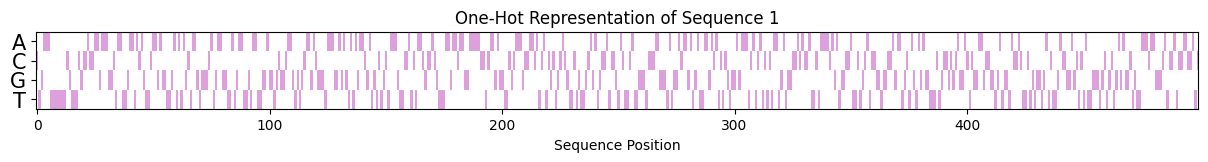

In [125]:
row = np.asarray(one_hot_feat.iloc[0])
image_2d = row.reshape((max_length, 4)).T
plum_colormap = ListedColormap(['white', '#DDA0DD'])
plt.figure(figsize=(15,1))
plt.imshow(image_2d, interpolation='nearest', aspect='auto',cmap=plum_colormap)
plt.yticks([0,1,2,3], ['A','C','G','T'],size=15)
plt.xlabel("Sequence Position")
plt.title("One-Hot Representation of Sequence 1")
plt.show()

### K-mer

<strong>What</strong>: Counts frequency of subsequences of length k (e.g., all 3-mers in a DNA string).

<strong>When to Use</strong>: Feature engineering for ML models, sequence comparison.

<strong>Drawbacks</strong>: Loses global order, large k leads to sparse high-dimensional space.

<div style="text-align: center;">
  <img src="https://github.com/fabianagoes/ismb_tutorial8/blob/main/images/Kmer.png?raw=1" alt="Description" width="500">
</div>

In [116]:
kmer_feat=pd.DataFrame()
for seq_set in sequences:
    kmer_feat=pd.concat([kmer_feat,pd.DataFrame(generate_kmer_features(sequences[seq_set],4))],ignore_index=True)#for each set-> generates features and appends to the final dataset using concat function. Soruce of feature generating fucntion: basic_encoding
kmer_feat.head(5)

,A,C,G,T,AA,AC,AG,AT,CA,CC,...,TTCG,TTCT,TTGA,TTGC,TTGG,TTGT,TTTA,TTTC,TTTG,TTTT
0,0.284,0.210,0.258,0.248,0.092184,0.044088,0.074148,0.074148,0.076152,0.044088,...,0.006036,0.010060,0.006036,0.002012,0.006036,0.002012,0.002012,0.006036,0.000000,0.008048
1,0.372,0.164,0.192,0.272,0.162325,0.048096,0.058116,0.102204,0.068136,0.014028,...,0.004024,0.002012,0.004024,0.000000,0.006036,0.002012,0.002012,0.006036,0.004024,0.006036
2,0.310,0.208,0.224,0.258,0.124248,0.056112,0.056112,0.072144,0.076152,0.058116,...,0.004024,0.000000,0.006036,0.000000,0.006036,0.008048,0.006036,0.000000,0.002012,0.006036
3,0.378,0.156,0.188,0.278,0.146293,0.056112,0.082164,0.094188,0.064128,0.024048,...,0.002012,0.008048,0.008048,0.002012,0.002012,0.004024,0.008048,0.008048,0.002012,0.012072
4,0.332,0.154,0.192,0.322,0.124248,0.042084,0.066132,0.100200,0.042084,0.032064,...,0.004024,0.006036,0.004024,0.004024,0.010060,0.010060,0.004024,0.006036,0.010060,0.006036


In [158]:
kmer_feat.iloc[0].rename('K-mer Percentage for Seq 1').head(10)

,K-mer Percentage for Seq 1
A,0.284000
C,0.210000
G,0.258000
T,0.248000
AA,0.092184
AC,0.044088
AG,0.074148
AT,0.074148
CA,0.076152
CC,0.044088


## Numerical Mapping


### Integer

<strong>What</strong>: Encodes nucleotides as integers (e.g., A=0, C=1, G=2, T=3).

<strong>When to Use</strong>: Simple ML models, sequence alignment, indexing.

<strong>Drawbacks</strong>: Imposes false ordinal relationships; lacks biological meaning.

<div style="text-align: center;">
  <img src="https://github.com/fabianagoes/ismb_tutorial8/blob/main/images/integer.png?raw=1" alt="Description" width="800">
</div>

In [21]:
integer_feat=pd.DataFrame()
for seq_set in sequences:
    integer_feat=pd.concat([integer_feat,pd.DataFrame(integer_features(sequences[seq_set],max_length))],ignore_index=True)#for each set-> generates features and appends to the final dataset using concat function. Soruce of feature generating fucntion: numerical_mapping
integer_feat.head(5)

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,1,0,3,2,2,2,0,0,0,0,...,0,1,1,2,2,1,1,2,0,1
1,2,0,2,0,3,1,0,1,3,2,...,3,3,3,3,0,3,1,0,1,2
2,1,2,2,1,3,3,0,2,1,1,...,2,3,1,0,3,0,0,2,2,2
3,2,2,1,3,2,2,3,0,1,0,...,2,0,1,0,3,3,1,2,2,0
4,0,3,2,3,1,2,2,2,0,0,...,0,3,2,3,2,2,0,0,2,0


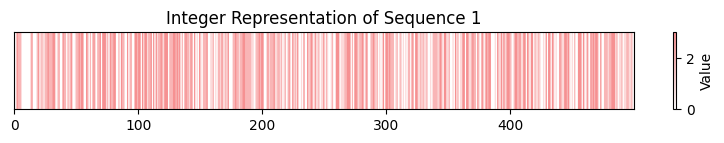

In [127]:
row = np.asarray(integer_feat.iloc[0])
data_2d = row[np.newaxis, :]
custom_cmap = LinearSegmentedColormap.from_list("custom_pink", ["#FFFFFF", '#F69192'])
plt.figure(figsize=(10, 1))
plt.imshow(data_2d, aspect='auto', cmap=custom_cmap, vmin=0, vmax=3)
plt.yticks([])
plt.colorbar(label='Value')
plt.title("Integer Representation of Sequence 1")
plt.show()


### Z-curve

<strong>What</strong>: 3D curve representation based on nucleotide distribution.

<strong>When to Use</strong>: Genome comparison, gene identification.

<strong>Drawbacks</strong>: Complex to compute and interpret; limited to certain applications.

<div style="text-align: center;">
  <img src="https://github.com/fabianagoes/ismb_tutorial8/blob/main/images/Z-curve.png?raw=1" alt="Description" width="700">
</div>

In [128]:
zcurve_feat=pd.DataFrame()
for seq_set in sequences:
    zcurve_feat=pd.concat([zcurve_feat,pd.DataFrame(zcurve_features(sequences[seq_set],max_length))],ignore_index=True)#for each set-> generates features and appends to the final dataset using concat function. Soruce of feature generating fucntion: numerical_mapping
zcurve_feat.head(5)

,0,1,2,3,4,5,6,7,8,9,...,1490,1491,1492,1493,1494,1495,1496,1497,1498,1499
0,-1,-2,-1,0,1,2,1,0,-1,-2,...,33,32,31,32,33,32,31,32,33,32
1,1,0,1,0,1,0,-1,-2,-1,0,...,147,146,145,144,145,144,143,144,143,144
2,-1,0,1,0,1,2,1,2,1,0,...,65,64,63,64,63,64,65,66,67,68
3,1,2,1,2,3,4,5,4,3,2,...,155,156,155,156,155,154,153,154,155,156
4,-1,0,1,2,1,2,3,4,3,2,...,149,148,149,148,149,150,151,152,153,154


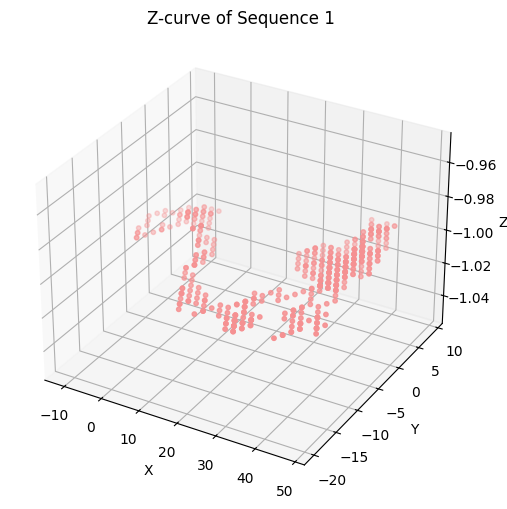

In [144]:
row=np.asarray(zcurve_feat.iloc[0])
x = row[0:len(row)//3]
y = row[len(row)//3:len(row)//3+max_length]
z = row[len(row)//3+max_length]

# Plot in 3D
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x, y, z, c='#F69192', marker='o', s=10)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Z-curve of Sequence 1')

plt.show()

## Pysico-Chemical Features

### GC Content

<strong>What</strong>: Proportion of G and C nucleotides.

<strong>When to Use</strong>: Genome classification, stability prediction.

<strong>Drawbacks</strong>: Very coarse; ignores sequence order and context.

<div style="text-align: center;">
  <img src="https://github.com/fabianagoes/ismb_tutorial8/blob/main/images/GC.png?raw=1" alt="Description" width="800">
</div>

In [145]:
gc_feat=pd.DataFrame()
for seq_set in sequences:
    gc_feat=pd.concat([gc_feat,pd.DataFrame(gc_content_features(sequences[seq_set]))],ignore_index=True)#for each set-> generates features and appends to the final dataset using concat function. Soruce of feature generating fucntion: physico_chemical
print('GC Content')
gc_feat.head(5)

GC Content


,GC_Content,G_Count,C_Count,Length
0,0.468,129,105,500
1,0.356,96,82,500
2,0.432,112,104,500
3,0.344,94,78,500
4,0.346,96,77,500


### Global Descriptors

<strong>What</strong>: Aggregated statistical features

<strong>When to Use</strong>: Classification tasks, especially in ML.

<strong>Drawbacks</strong>: May lose local sequence information; interpretation can be difficult.

<div style="text-align: center;">
  <img src="https://github.com/fabianagoes/ismb_tutorial8/blob/main/images/GD.png?raw=1" alt="Description" width="500">
</div>

In [146]:
gd_feat=pd.DataFrame()
for seq_set in sequences:
    gd_feat=pd.concat([gd_feat,pd.DataFrame(global_descriptor_features(sequences[seq_set]))],ignore_index=True)#for each set-> generates features and appends to the final dataset using concat function. Soruce of feature generating fucntion: physico_chemical
gd_feat.head(5)

,Comp_A,Comp_C,Comp_G,Comp_T,Trans_CT,Trans_TG,Trans_GA,Trans_AA,Trans_AT,Trans_TT,...,Dist_G_0,Dist_G_1,Dist_G_2,Dist_G_3,Dist_G_4,Dist_T_0,Dist_T_1,Dist_T_2,Dist_T_3,Dist_T_4
0,0.284,0.210,0.258,0.248,0.052104,0.078156,0.070140,0.092184,0.074148,0.062124,...,0.004,0.236,0.520,0.784,0.966,0.002,0.192,0.500,0.750,0.996
1,0.372,0.164,0.192,0.272,0.056112,0.068136,0.062124,0.162325,0.102204,0.060120,...,0.008,0.206,0.490,0.826,0.990,0.002,0.236,0.500,0.716,0.994
2,0.310,0.208,0.224,0.258,0.050100,0.078156,0.048096,0.124248,0.072144,0.064128,...,0.008,0.274,0.500,0.766,0.988,0.012,0.220,0.502,0.718,0.992
3,0.378,0.156,0.188,0.278,0.038076,0.048096,0.078156,0.146293,0.094188,0.096192,...,0.006,0.212,0.416,0.720,0.990,0.014,0.344,0.600,0.782,0.998
4,0.332,0.154,0.192,0.322,0.058116,0.068136,0.074148,0.124248,0.100200,0.108216,...,0.002,0.268,0.540,0.784,0.986,0.000,0.270,0.514,0.732,0.998


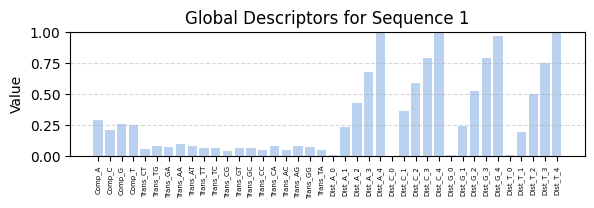

In [148]:
row = gd_feat.iloc[0]
plt.figure(figsize=(6, 2))
plt.bar(row.index, row.values, color='#BAD2F0')
plt.ylim(0, 1)
plt.ylabel("Value")
plt.title("Global Descriptors for Sequence 1")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.xticks(rotation=90,size=5)
plt.show()


## Advanced Representations

### Chaos Game Representation

<strong>What</strong>: Fractal-like image encoding sequence as 2D patterns.

<strong>When to Use</strong>: Visual pattern recognition, deep learning on images.

<strong>Drawbacks</strong>: Computationally heavy for long sequences; hard to interpret directly.

<div style="text-align: center;">
  <img src="https://github.com/fabianagoes/ismb_tutorial8/blob/main/images/CGR.png?raw=1" alt="Description" width="500">
</div>


In [34]:
cgr_feat=pd.DataFrame()
for seq_set in sequences:
    cgr_feat=pd.concat([cgr_feat,pd.DataFrame(classifical_chaos_features(sequences[seq_set],max_length))],ignore_index=True)#for each set-> generates features and appends to the final dataset using concat function. Soruce of feature generating fucntion: CGR
cgr_feat.head(5)

,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
0,-0.5,-0.75,0.125,0.5625,0.78125,0.890625,-0.054688,-0.527344,-0.763672,-0.881836,...,0.595453,-0.202273,-0.601137,0.199432,0.599716,-0.200142,-0.600071,0.199964,0.599982,-0.200009
1,0.5,-0.25,0.375,-0.3125,0.34375,-0.328125,-0.664062,-0.832031,0.083984,0.541992,...,-0.165067,-0.582534,-0.791267,-0.895633,0.052183,-0.473908,-0.736954,0.131523,-0.434239,0.282881
2,-0.5,0.25,0.625,-0.1875,0.40625,0.703125,-0.148438,0.425781,-0.287109,-0.643555,...,0.483972,-0.258014,-0.629007,0.185497,-0.407252,0.296374,0.648187,0.824094,0.912047,0.956023
3,0.5,0.75,-0.125,0.4375,0.71875,0.859375,0.929688,-0.035156,-0.517578,-0.758789,...,0.616153,0.808076,-0.095962,0.452019,-0.273990,-0.636995,-0.818498,0.090751,0.545376,0.772688
4,-0.5,0.25,0.625,0.8125,-0.09375,0.453125,0.726562,0.863281,-0.068359,-0.534180,...,0.343174,-0.328413,0.335794,-0.332103,0.333948,0.666974,0.833487,0.916744,0.958372,0.979186


Text(0.5, 1.0, 'Chaos game Representation for Sequence 1')

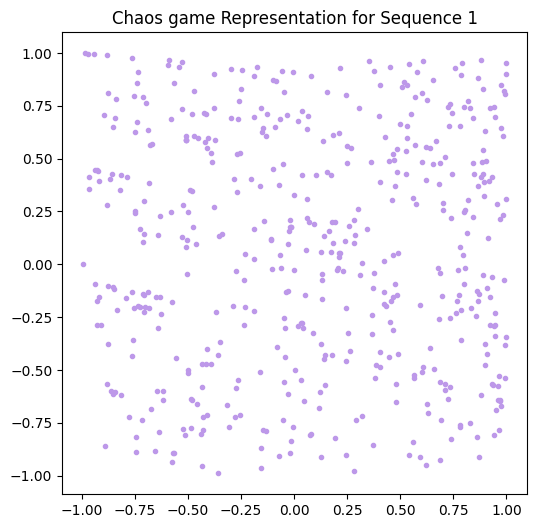

In [149]:
CGR_x=cgr_feat.iloc[0,:max_length]
CGR_y=cgr_feat.iloc[0,max_length:]
plt.figure(figsize=(6, 6))
plt.scatter(CGR_x, CGR_y, marker='.',color='#BD98E9')
plt.title(f"Chaos game Representation for Sequence 1")


# Univariate Analysis

- Load the feature dataframes one by one
- Run them through 4 different models
- Store all accuracies and get the boxplot for comparison

<div style="text-align: center;">
  <img src="https://github.com/fabianagoes/ismb_tutorial8/blob/main/images/univar.png?raw=1" alt="Description" width="1000">
</div>

Training Models: 100%|██████████| 4/4 [03:40<00:00, 55.01s/it]


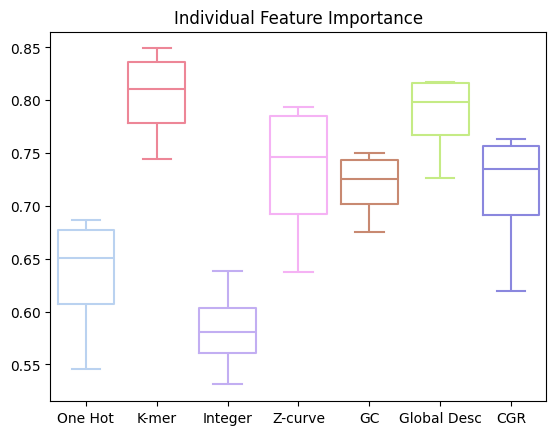

In [153]:
feats=[one_hot_feat,kmer_feat,integer_feat,zcurve_feat,gc_feat,gd_feat,cgr_feat]
accuracy={}
feat_names=['One Hot','K-mer','Integer','Z-curve','GC','Global Desc','CGR']
colors = ['#BAD2F0', '#ED8697', '#C2AEF2', '#F5B2F4', '#C88971', '#C5EB85', '#8A87DE']

for feat_ind in range(0,7):
    feat=(feats[feat_ind]).fillna(0)#replace any NaNs with 0
    train_feats=feat[label_distr['Name']=='Train']#extract train data
    test_feats=feat[label_distr['Name']=='Test']#extract test data
    train_labels=label_distr[label_distr['Name']=='Train']['Labels']#extract train labels
    test_labels=label_distr[label_distr['Name']=='Test']['Labels']#extract test labels
    accuracy[feat_names[feat_ind]]=run_models(train_feats,train_labels,test_feats,test_labels)#source of training function: ML_models

sns.boxplot(accuracy, fill=False, palette=colors)
plt.title('Individual Feature Importance')
plt.show()


# Multivariate Analysis

- Combine all features while dropping each feature one at a time
- Run them through 4 different models
- Store all accuracies and get the boxplot for comparison

<div style="text-align: center;">
  <img src="https://github.com/fabianagoes/ismb_tutorial8/blob/main/images/drop.png?raw=1" alt="Description" width="1000">
</div>

Training Models: 100%|██████████| 4/4 [00:06<00:00,  1.68s/it]


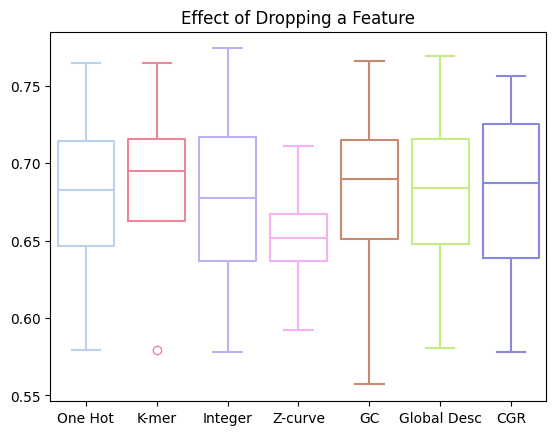

In [152]:
feats=[one_hot_feat,kmer_feat,integer_feat,zcurve_feat,gc_feat,gd_feat,cgr_feat]
accuracy={}
feat_names=['One Hot','K-mer','Integer','Z-curve','GC','Global Desc','CGR']
colors = ['#BAD2F0', '#ED8697', '#C2AEF2', '#F5B2F4', '#C88971', '#C5EB85', '#8A87DE']

for feat_ind in range(0,7):
    combined_feat_set=pd.concat(feats[:feat_ind] + feats[feat_ind+1:],axis=1)#combine feature dfs for all except current index
    combined_feat_set.columns=[i for i in range(0,len(combined_feat_set.keys()))]#rename columns to prevent duplicate keys
    combined_feat_set=combined_feat_set.fillna(0)#replace any NaNs with 0
    train_feats=(combined_feat_set[label_distr['Name']=='Train']).sample(n=100, random_state=42)  #extract train data san sample 100 elements (for faster processing)
    test_feats=combined_feat_set[label_distr['Name']=='Test']#extract test data
    train_labels=(label_distr[label_distr['Name']=='Train']['Labels']).loc[train_feats.index]#extract train labels fpr the indices of train samples
    test_labels=label_distr[label_distr['Name']=='Test']['Labels']#extract test labels
    accuracy[feat_names[feat_ind]]=run_models(train_feats,train_labels,test_feats,test_labels)#source of training function: ML_models

sns.boxplot(accuracy, fill=False, palette=colors)
plt.title('Effect of Dropping a Feature')
plt.show()


# Conclusions

Write a report below with your findings.

#### Dataset 1 tested:
------------------------------

*Add findings here*

*-*

*-*

#### Dataset 2 tested:
------------------------------

*Add findings here*

*-*

*-*

#### Dataset 3 tested:
------------------------------

*Add findings here*

*-*

*-*